In [1]:
#importing the Libraies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Reading the Dataset
dataset = pd.read_csv('50_Startups.csv')

In [3]:
dataset

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [7]:
datasets=pd.get_dummies(dataset,drop_first=True)

In [9]:
datasets

,R&D Spend,Administration,Marketing Spend,Profit,State_Florida,State_New York
0,165349.20,136897.80,471784.10,192261.83,False,True
1,162597.70,151377.59,443898.53,191792.06,False,False
2,153441.51,101145.55,407934.54,191050.39,True,False
3,144372.41,118671.85,383199.62,182901.99,False,True
4,142107.34,91391.77,366168.42,166187.94,True,False
5,131876.90,99814.71,362861.36,156991.12,False,True
6,134615.46,147198.87,127716.82,156122.51,False,False
7,130298.13,145530.06,323876.68,155752.60,True,False
8,120542.52,148718.95,311613.29,152211.77,False,True
9,123334.88,108679.17,304981.62,149759.96,False,False


In [11]:
dataset.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'State', 'Profit'], dtype='object')

In [13]:
indep=datasets[['R&D Spend','Administration', 'Marketing Spend','State_Florida', 'State_New York']]
dep=datasets[['Profit']]

In [15]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
param_grid={'criterion': ['squared_error', 'absolute_error', 'friedman_mse'],'max_features': [None,'sqrt','log2'],'splitter':['best','random']}
grid=GridSearchCV(DecisionTreeRegressor(),param_grid,refit=True, verbose=3,n_jobs=-1)
grid.fit(indep,dep)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


GridSearchCV(estimator=DecisionTreeRegressor(), n_jobs=-1,
             param_grid={'criterion': ['squared_error', 'absolute_error',
                                       'friedman_mse'],
                         'max_features': [None, 'sqrt', 'log2'],
                         'splitter': ['best', 'random']},
             verbose=3)

In [16]:
grid.best_score_

-5.165700375462593

In [19]:
re=grid.cv_results_
re

{'mean_fit_time': array([0.00485144, 0.00395155, 0.00484023, 0.0038722 , 0.00341182,
        0.00366211, 0.00352044, 0.00323358, 0.0039042 , 0.00388536,
        0.0028265 , 0.00281935, 0.00399756, 0.00272951, 0.00342793,
        0.00407214, 0.0027729 , 0.00321374]),
 'std_fit_time': array([1.70376818e-03, 1.25475853e-03, 1.13690085e-03, 1.03408742e-03,
        8.07867294e-04, 9.21657523e-04, 1.01867252e-03, 7.73801397e-04,
        8.58144130e-04, 1.34207990e-03, 9.87040310e-04, 9.83052109e-04,
        1.49551884e-03, 3.00299443e-04, 1.03989086e-03, 3.00832478e-05,
        6.26382057e-04, 9.83832452e-04]),
 'mean_score_time': array([0.00397062, 0.00420027, 0.00294242, 0.0023057 , 0.00373006,
        0.00287328, 0.00322428, 0.00292234, 0.00233784, 0.00255346,
        0.00346899, 0.003265  , 0.00247636, 0.0028245 , 0.00297933,
        0.00293684, 0.00214992, 0.0020083 ]),
 'std_score_time': array([0.00010017, 0.00130872, 0.00149933, 0.00030308, 0.00141144,
        0.00065267, 0.00073688, 

In [21]:
table=pd.DataFrame.from_dict(re)

In [23]:
table

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_features,param_splitter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.004851,0.001704,0.003971,0.000100,squared_error,None,best,"{'criterion': 'squared_error', 'max_features':...",-6.462478,-2.803184,-12.875197,-2.017470,-1.670174,-5.165700,4.214962,1
1,0.003952,0.001255,0.004200,0.001309,squared_error,None,random,"{'criterion': 'squared_error', 'max_features':...",-7.684315,-4.261826,-22.888443,-9.597334,-8.021012,-10.490586,6.438574,9
2,0.004840,0.001137,0.002942,0.001499,squared_error,sqrt,best,"{'criterion': 'squared_error', 'max_features':...",-7.251046,-19.258148,-35.202309,-5.679846,-5.561629,-14.590595,11.501491,11
3,0.003872,0.001034,0.002306,0.000303,squared_error,sqrt,random,"{'criterion': 'squared_error', 'max_features':...",-4.723019,-21.302052,-30.800226,-15.865982,-2.562108,-15.050677,10.492069,12
4,0.003412,0.000808,0.003730,0.001411,squared_error,log2,best,"{'criterion': 'squared_error', 'max_features':...",-3.848924,-9.556309,-17.898056,-5.190398,-3.821088,-8.062955,5.347193,8
5,0.003662,0.000922,0.002873,0.000653,squared_error,log2,random,"{'criterion': 'squared_error', 'max_features':...",-6.856567,-3.574501,-53.570323,-52.219367,-6.635978,-24.571347,23.159068,17
6,0.003520,0.001019,0.003224,0.000737,absolute_error,None,best,"{'criterion': 'absolute_error', 'max_features'...",-4.860764,-2.938654,-13.183380,-2.400382,-2.668512,-5.210338,4.079433,2
7,0.003234,0.000774,0.002922,0.001431,absolute_error,None,random,"{'criterion': 'absolute_error', 'max_features'...",-5.389195,-4.603826,-93.728494,-3.167748,-1.670174,-21.711887,36.030718,15
8,0.003904,0.000858,0.002338,0.000484,absolute_error,sqrt,best,"{'criterion': 'absolute_error', 'max_features'...",-9.868099,-9.412704,-11.286960,-3.454148,-3.188230,-7.442028,3.422013,7
9,0.003885,0.001342,0.002553,0.000783,absolute_error,sqrt,random,"{'criterion': 'absolute_error', 'max_features'...",-12.714944,-12.825590,-46.170940,-15.420054,-4.412943,-18.308894,14.415931,13


# grid.best_score_ and the mean_test_score (rank_test_score == 1) will match 
# only if GridSearchCV, cv_results_, and the table are run sequentially in order;
# otherwise, running cells out of order may show different values


In [26]:
table.loc[table['rank_test_score'] == 1, 'mean_test_score']


0   -5.1657
Name: mean_test_score, dtype: float64

In [28]:
grid.best_score_


-5.165700375462593

In [30]:

best_tree=grid.best_estimator_

# otherwise, running cells out of order may show different values,below best score is different because we are not running sequential order


In [33]:
print("the R_score value for best Paramater is:",grid.best_params_,"\n and R Score is ", grid.best_score_)

the R_score value for best Paramater is: {'criterion': 'squared_error', 'max_features': None, 'splitter': 'best'} 
 and R Score is  -5.165700375462593


In [35]:
table

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_features,param_splitter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.004851,0.001704,0.003971,0.000100,squared_error,None,best,"{'criterion': 'squared_error', 'max_features':...",-6.462478,-2.803184,-12.875197,-2.017470,-1.670174,-5.165700,4.214962,1
1,0.003952,0.001255,0.004200,0.001309,squared_error,None,random,"{'criterion': 'squared_error', 'max_features':...",-7.684315,-4.261826,-22.888443,-9.597334,-8.021012,-10.490586,6.438574,9
2,0.004840,0.001137,0.002942,0.001499,squared_error,sqrt,best,"{'criterion': 'squared_error', 'max_features':...",-7.251046,-19.258148,-35.202309,-5.679846,-5.561629,-14.590595,11.501491,11
3,0.003872,0.001034,0.002306,0.000303,squared_error,sqrt,random,"{'criterion': 'squared_error', 'max_features':...",-4.723019,-21.302052,-30.800226,-15.865982,-2.562108,-15.050677,10.492069,12
4,0.003412,0.000808,0.003730,0.001411,squared_error,log2,best,"{'criterion': 'squared_error', 'max_features':...",-3.848924,-9.556309,-17.898056,-5.190398,-3.821088,-8.062955,5.347193,8
5,0.003662,0.000922,0.002873,0.000653,squared_error,log2,random,"{'criterion': 'squared_error', 'max_features':...",-6.856567,-3.574501,-53.570323,-52.219367,-6.635978,-24.571347,23.159068,17
6,0.003520,0.001019,0.003224,0.000737,absolute_error,None,best,"{'criterion': 'absolute_error', 'max_features'...",-4.860764,-2.938654,-13.183380,-2.400382,-2.668512,-5.210338,4.079433,2
7,0.003234,0.000774,0.002922,0.001431,absolute_error,None,random,"{'criterion': 'absolute_error', 'max_features'...",-5.389195,-4.603826,-93.728494,-3.167748,-1.670174,-21.711887,36.030718,15
8,0.003904,0.000858,0.002338,0.000484,absolute_error,sqrt,best,"{'criterion': 'absolute_error', 'max_features'...",-9.868099,-9.412704,-11.286960,-3.454148,-3.188230,-7.442028,3.422013,7
9,0.003885,0.001342,0.002553,0.000783,absolute_error,sqrt,random,"{'criterion': 'absolute_error', 'max_features'...",-12.714944,-12.825590,-46.170940,-15.420054,-4.412943,-18.308894,14.415931,13


In [37]:
imp=best_tree.feature_importances_

In [39]:
imp

array([8.67361803e-01, 7.83412548e-03, 1.24441390e-01, 2.62667521e-05,
       3.36414746e-04])

In [41]:
imp=best_tree.max_features_

In [43]:
imp

5

In [45]:
imp=best_tree.tree_

In [47]:
imp

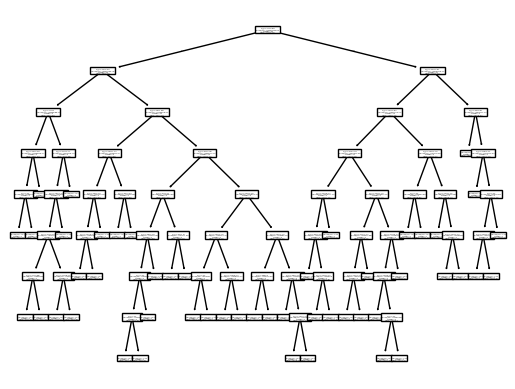

In [49]:
from sklearn import tree
best_tree=grid.best_estimator_
tree.plot_tree(best_tree)
plt.show()

In [50]:
rd_input=float(input("R&D:"))
admin_input=float(input("Admin"))
mark_input=float(input("Marketing "))
fol_input=int(input("State_flo 0 or 1:"))
new_input=int(input("State_new 0 or 1:"))

R&D: 165349.2
Admin 136897.8
Marketing  471784.1
State_flo 0 or 1: 0
State_new 0 or 1: 1


In [51]:
result=grid.predict([[rd_input,admin_input,mark_input,fol_input,new_input]])

C:\Users\alkar\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [55]:
result

array([192261.83])